Data from the Energy Minimization process - we want to analyze the structural differences.

In [26]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import twistaly as tw

files_dir = "H:/colproj-data/struct-aly/files-tw0" # Windows path

u_pre = md.Universe(files_dir + "/em.tpr", files_dir + "/colfib-solvion.gro")
u_pos = md.Universe(files_dir + "/em.tpr", files_dir + "/em.xtc")

Compare structures

In [27]:
chains_pre = u_pre.select_atoms("protein").fragments
chains_pos = u_pos.select_atoms("protein").fragments

com_pre = u_pre.select_atoms("protein").center_of_mass() /10
com_pos = u_pos.select_atoms("protein").center_of_mass() /10

In [28]:
group = "name CA"
mol = 24

# --- Pre ---
molecule = chains_pre[3*mol:3*mol + 3]
molecule_coords = (molecule[0].select_atoms(group) + molecule[1].select_atoms(group)+ molecule[2].select_atoms(group)).positions /10
# molecule_mean_filt = tw.remove_ends(0.5, molecule_coords) / 10
rad_pre, phi_pre, z_pre = tw.cyl_proj(molecule_coords, com_pre[1], com_pre[0])

# --- Pos ---
molecule = chains_pos[3*mol:3*mol + 3]
molecule_coords = (molecule[0].select_atoms(group) + molecule[1].select_atoms(group)+ molecule[2].select_atoms(group)).positions /10
# molecule_mean_filt = tw.remove_ends(0.5, molecule_coords) / 10
rad_pos, phi_pos, z_pos = tw.cyl_proj(molecule_coords, com_pos[1], com_pos[0])

Plot to see differences, then we compare more numerically.

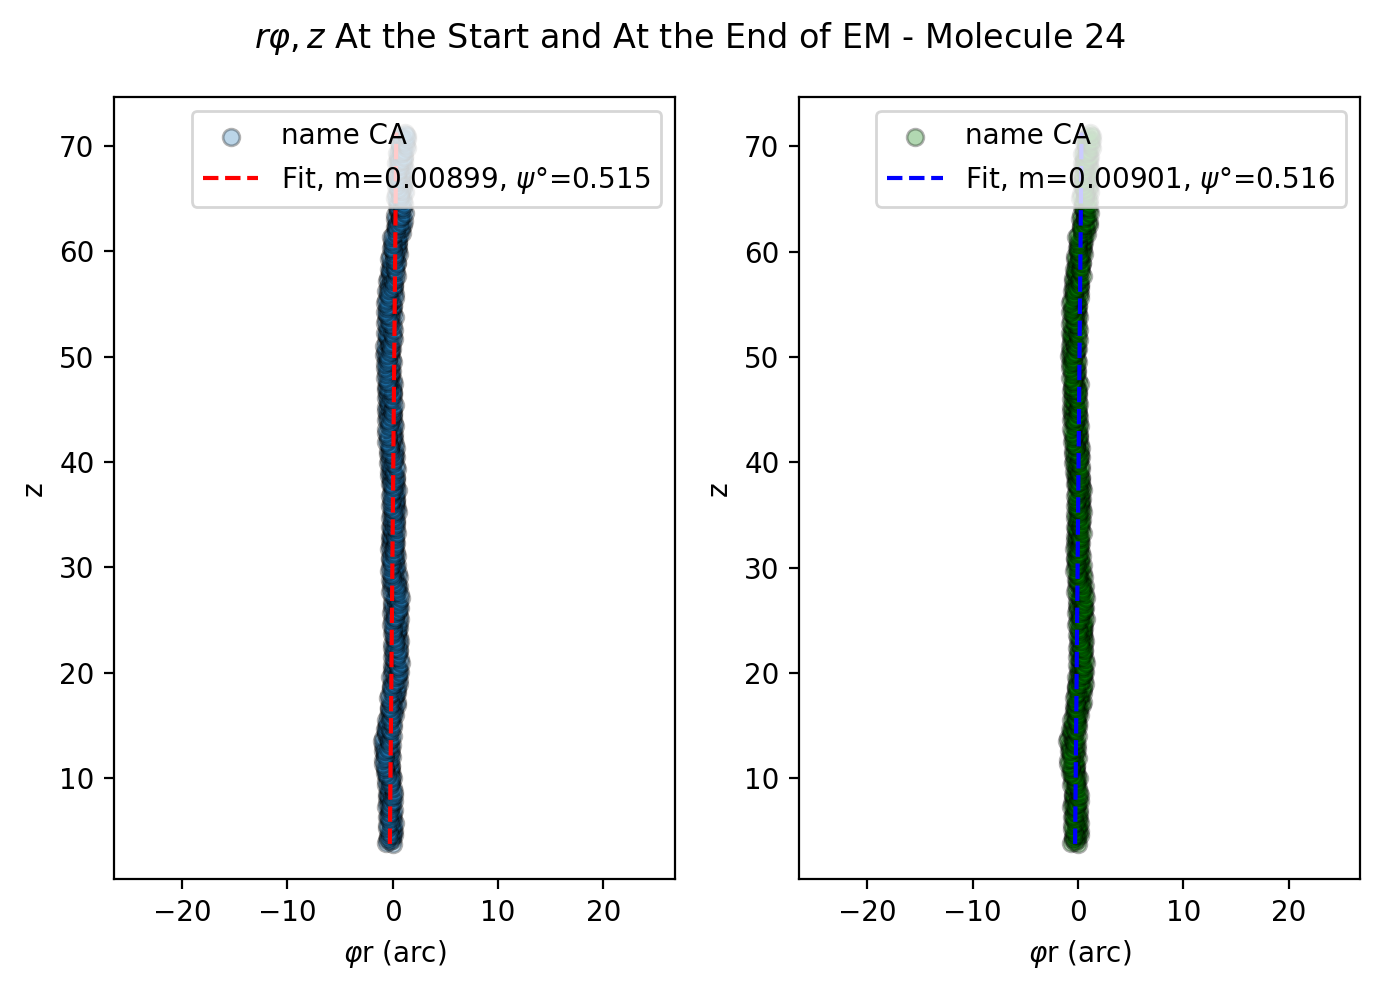

In [29]:
arc_pre = rad_pre*phi_pre
arc_pos = rad_pos*phi_pos

fig, ax = plt.subplots(1, 2, figsize=(7,5), dpi=200)

ax[0].scatter(arc_pre, z_pre, alpha=0.3, edgecolor='k', label=group)
m, b, _ = tw.ortreglinfit(z_pre, arc_pre)
ax[0].plot(m*z_pre + b, z_pre, linestyle='dashed', color='r', label=rf'Fit, m={m:.5f}, $\psi$°={np.rad2deg(np.atan(m)):.3f}')

ax[0].axis('equal')
ax[0].set_xlabel(r'$\varphi$r (arc)')
ax[0].set_ylabel(r'z')
ax[0].legend()

ax[1].scatter(arc_pos, z_pos, color='g', alpha=0.3, edgecolor='k', label=group)
# --- Orthogonal Regression ---
m, b, _ = tw.ortreglinfit(z_pos, arc_pos)
ax[1].plot(m*z_pos + b, z_pos, linestyle='dashed', color='b', label=rf'Fit, m={m:.5f}, $\psi$°={np.rad2deg(np.atan(m)):.3f}')

ax[1].axis('equal')
ax[1].set_xlabel(r'$\varphi$r (arc)')
ax[1].set_ylabel(r'z')
ax[1].legend()

plt.suptitle(rf'$r\varphi, z$ At the Start and At the End of EM - Molecule {mol}')
plt.tight_layout()
plt.show()

Routine of Whole Spectrum

In [30]:
num_mols = int(len(chains_pre)/3)

group = "name CA"

m_pre = np.zeros(num_mols)
m_pos = np.zeros(num_mols)
m_rad = np.zeros(num_mols)
var_l = np.zeros(num_mols)

for mol in range(num_mols):
    # --- Pre ---
    molecule = chains_pre[3*mol:3*mol + 3]
    molecule_coords = (molecule[0].select_atoms(group) + molecule[1].select_atoms(group)+ molecule[2].select_atoms(group)).positions /10
    rad_pre, phi_pre, z_pre = tw.cyl_proj(molecule_coords, com_pre[1], com_pre[0])
    arc_pre = rad_pre*phi_pre
    m_pre[mol], b, _ = tw.ortreglinfit(z_pre, arc_pre)
    # --- Pos ---
    molecule = chains_pos[3*mol:3*mol + 3]
    molecule_coords = (molecule[0].select_atoms(group) + molecule[1].select_atoms(group)+ molecule[2].select_atoms(group)).positions /10
    rad_pos, phi_pos, z_pos = tw.cyl_proj(molecule_coords, com_pos[1], com_pos[0])
    arc_pos = rad_pos*phi_pos
    m_pos[mol], b, var_l[mol] = tw.ortreglinfit(z_pos, arc_pos)
    m_rad[mol] = (np.mean(rad_pre) + np.mean(rad_pos))/2

psi_pre = np.rad2deg(np.atan(m_pre))
psi_pos = np.rad2deg(np.atan(m_pos))

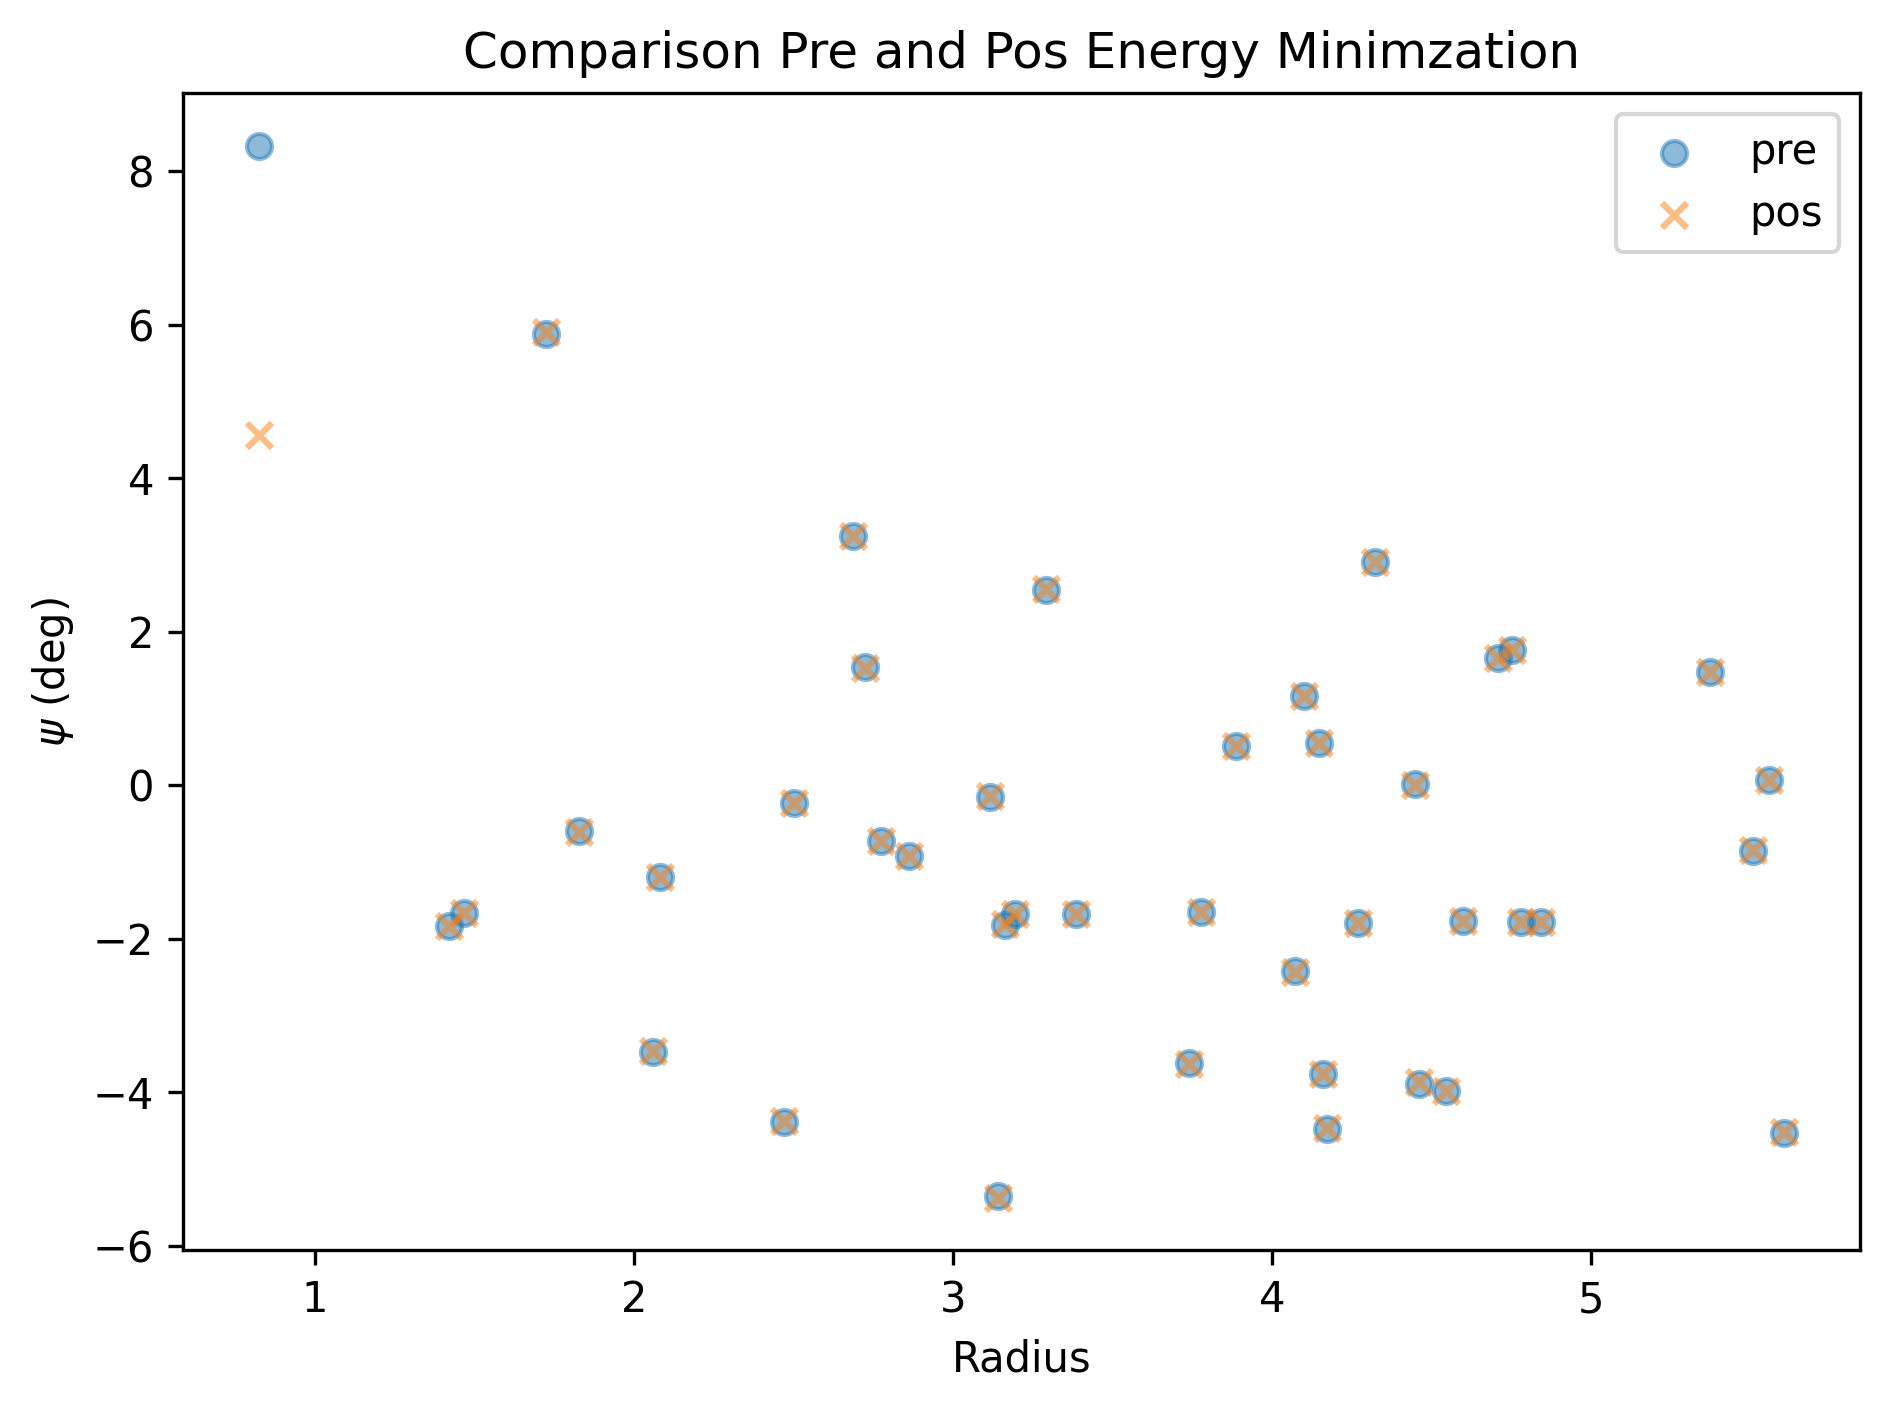

In [31]:
plt.figure(dpi=300)

plt.scatter(m_rad, psi_pre, label="pre", alpha=0.5)
plt.scatter(m_rad, psi_pos, label="pos", alpha=0.5, marker="x")

plt.xlabel("Radius")
plt.ylabel(r"$\psi$ (deg)")
plt.title("Comparison Pre and Pos Energy Minimzation")

plt.tight_layout()
plt.legend()
plt.show()

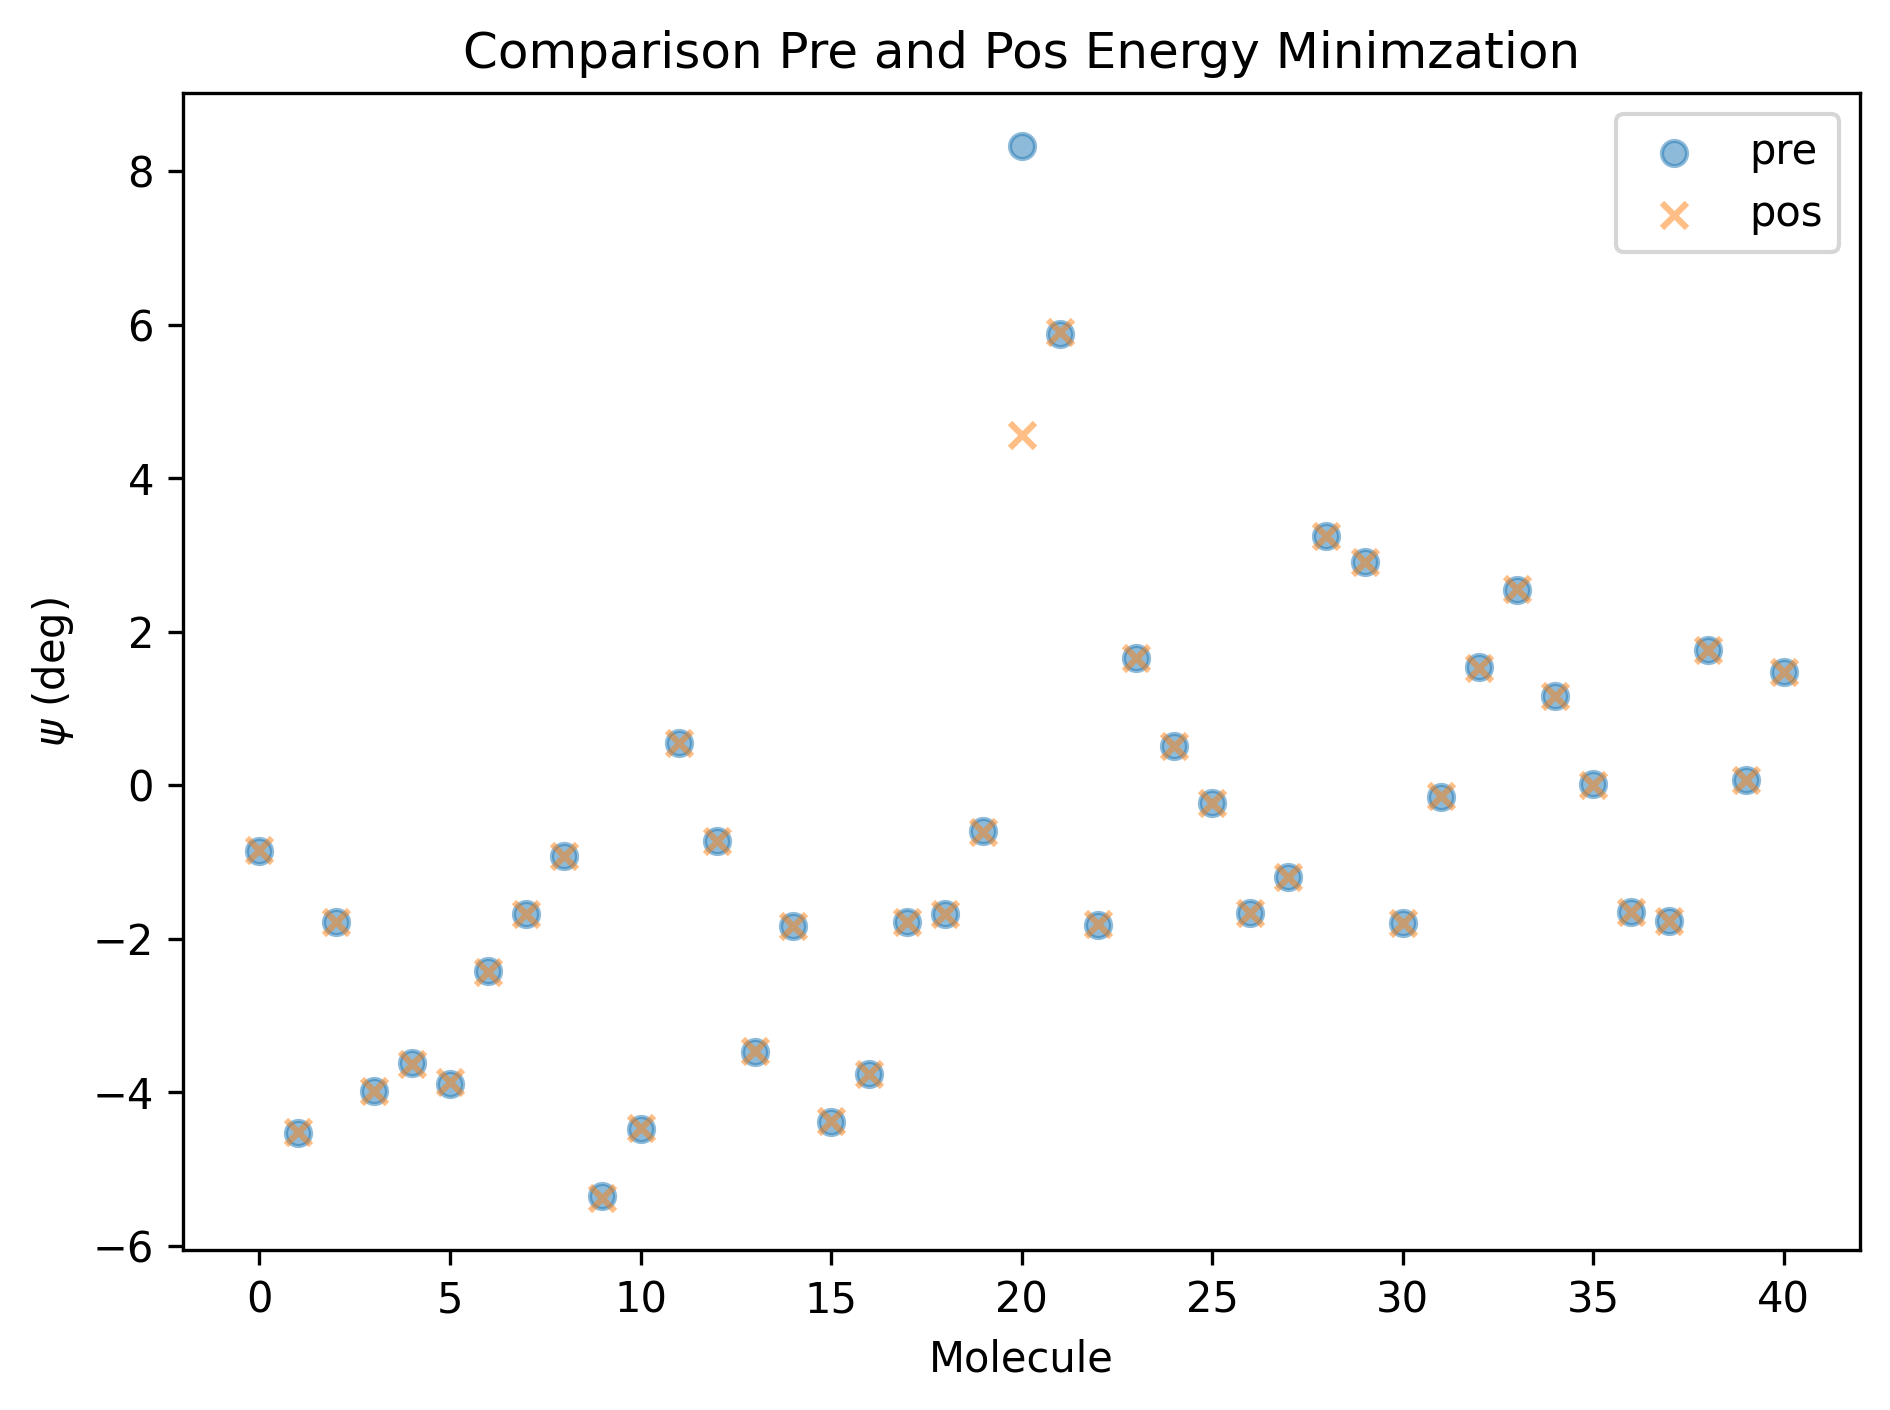

In [32]:
plt.figure(dpi=300)

plt.scatter(range(num_mols), psi_pre, label="pre", alpha=0.5)
plt.scatter(range(num_mols), psi_pos, label="pos", alpha=0.5, marker="x")

plt.xlabel("Molecule")
plt.ylabel(r"$\psi$ (deg)")
plt.title("Comparison Pre and Pos Energy Minimzation")
plt.tight_layout()
plt.legend()
plt.show()

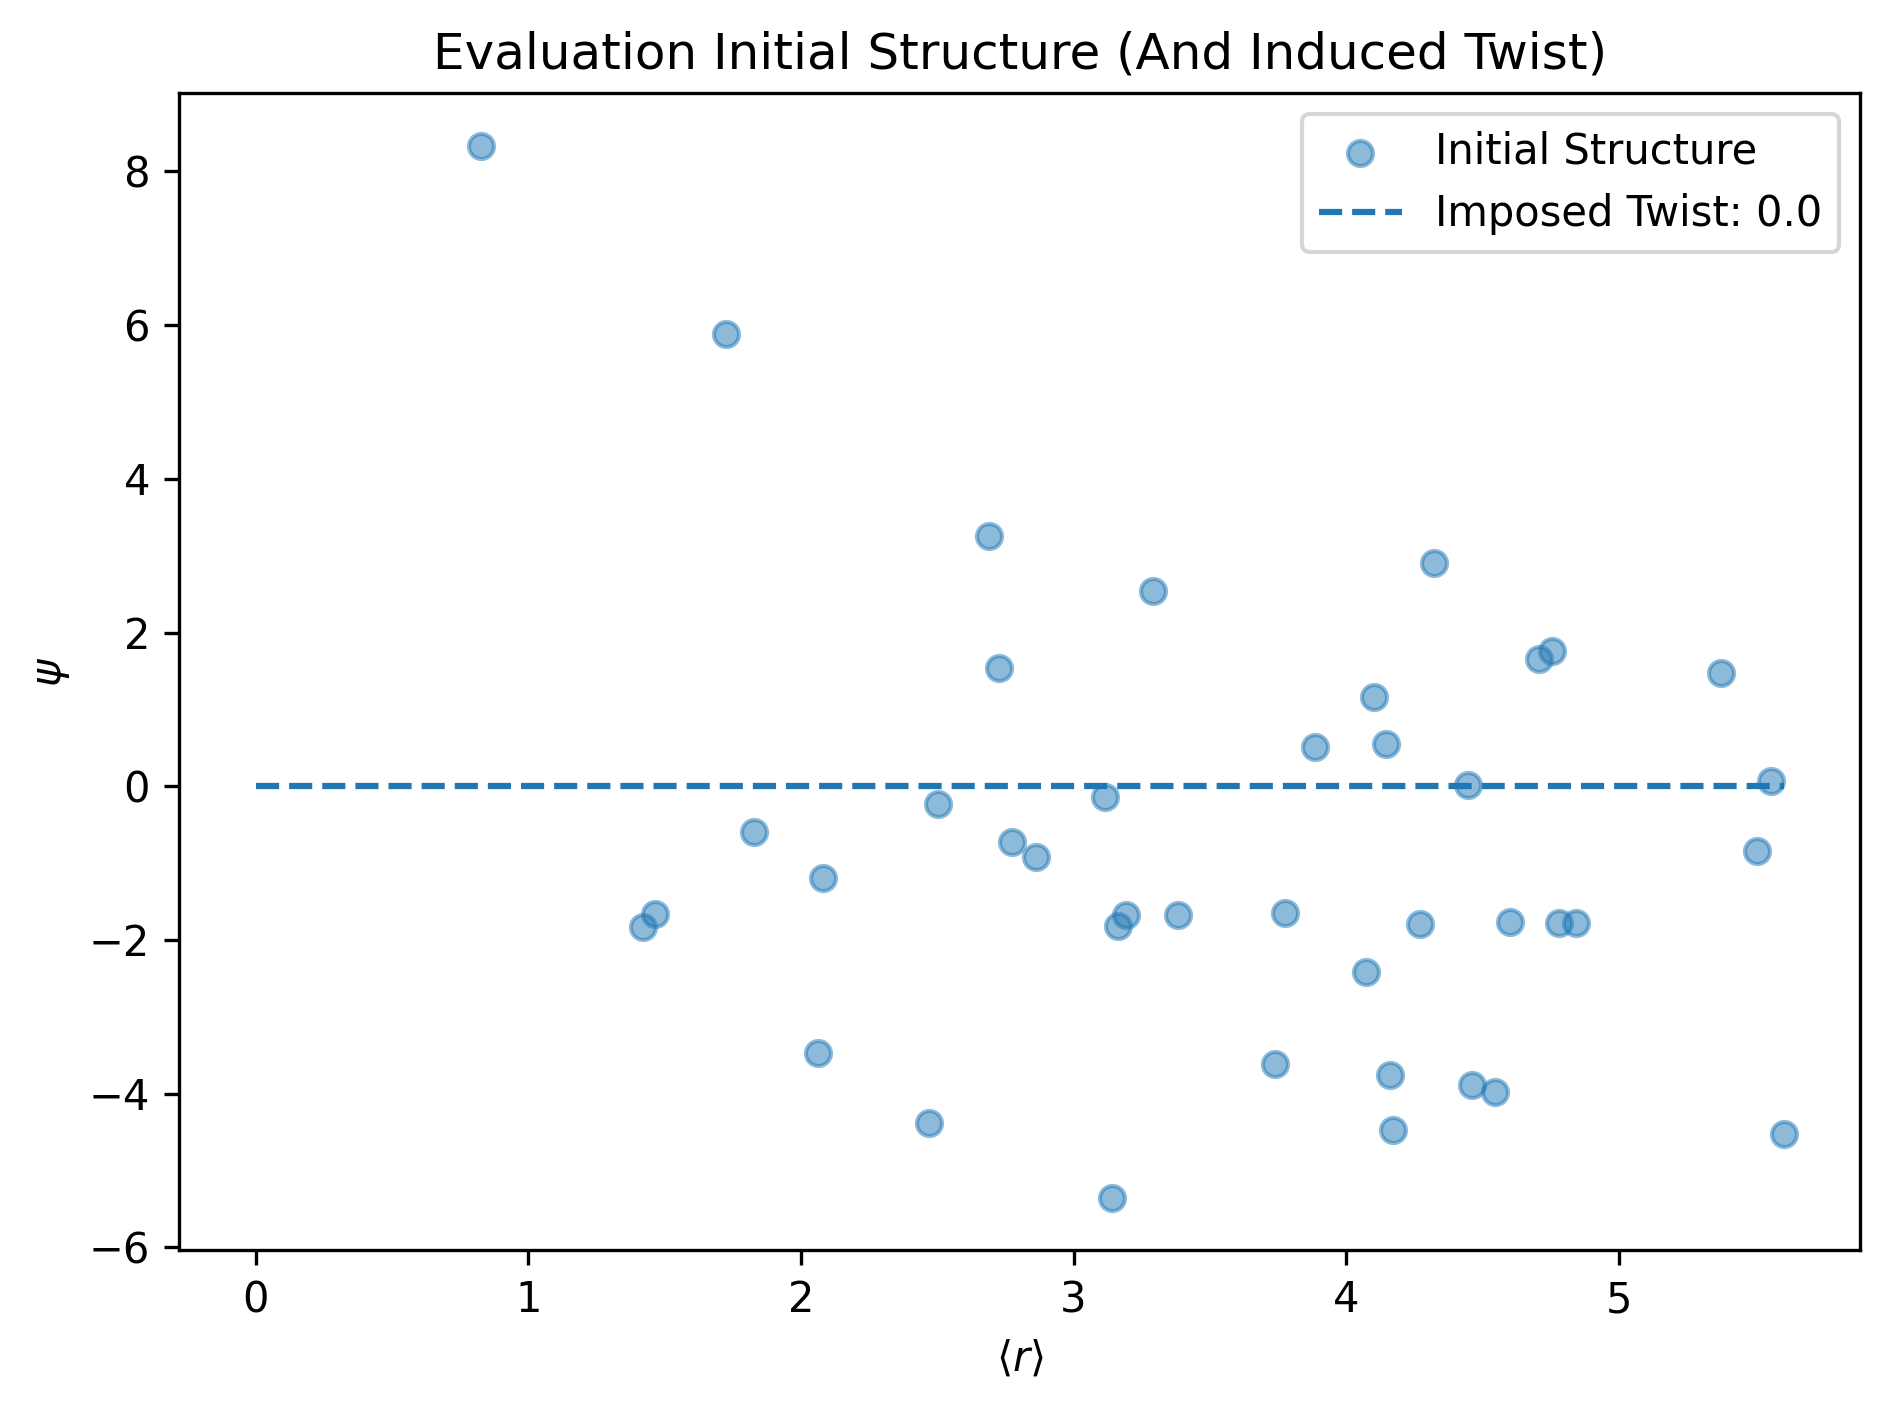

In [33]:
# --- Twist Imposed ---
plt.figure(dpi=300)

rad_range = np.linspace(0, max(m_rad), 100)
twist = 0.0

plt.scatter(m_rad, psi_pre, label="Initial Structure", alpha=0.5)
plt.plot(rad_range, np.rad2deg(np.tan(rad_range*twist)), label=f"Imposed Twist: {twist}", linestyle="dashed")
#plt.scatter(m_rad/10, m_pos, label="pos", alpha=0.5, marker="x")

plt.xlabel(r"$\langle r \rangle$")
plt.ylabel(r"$\psi$")
plt.title("Evaluation Initial Structure (And Induced Twist)")

plt.tight_layout()
plt.legend()
plt.show()

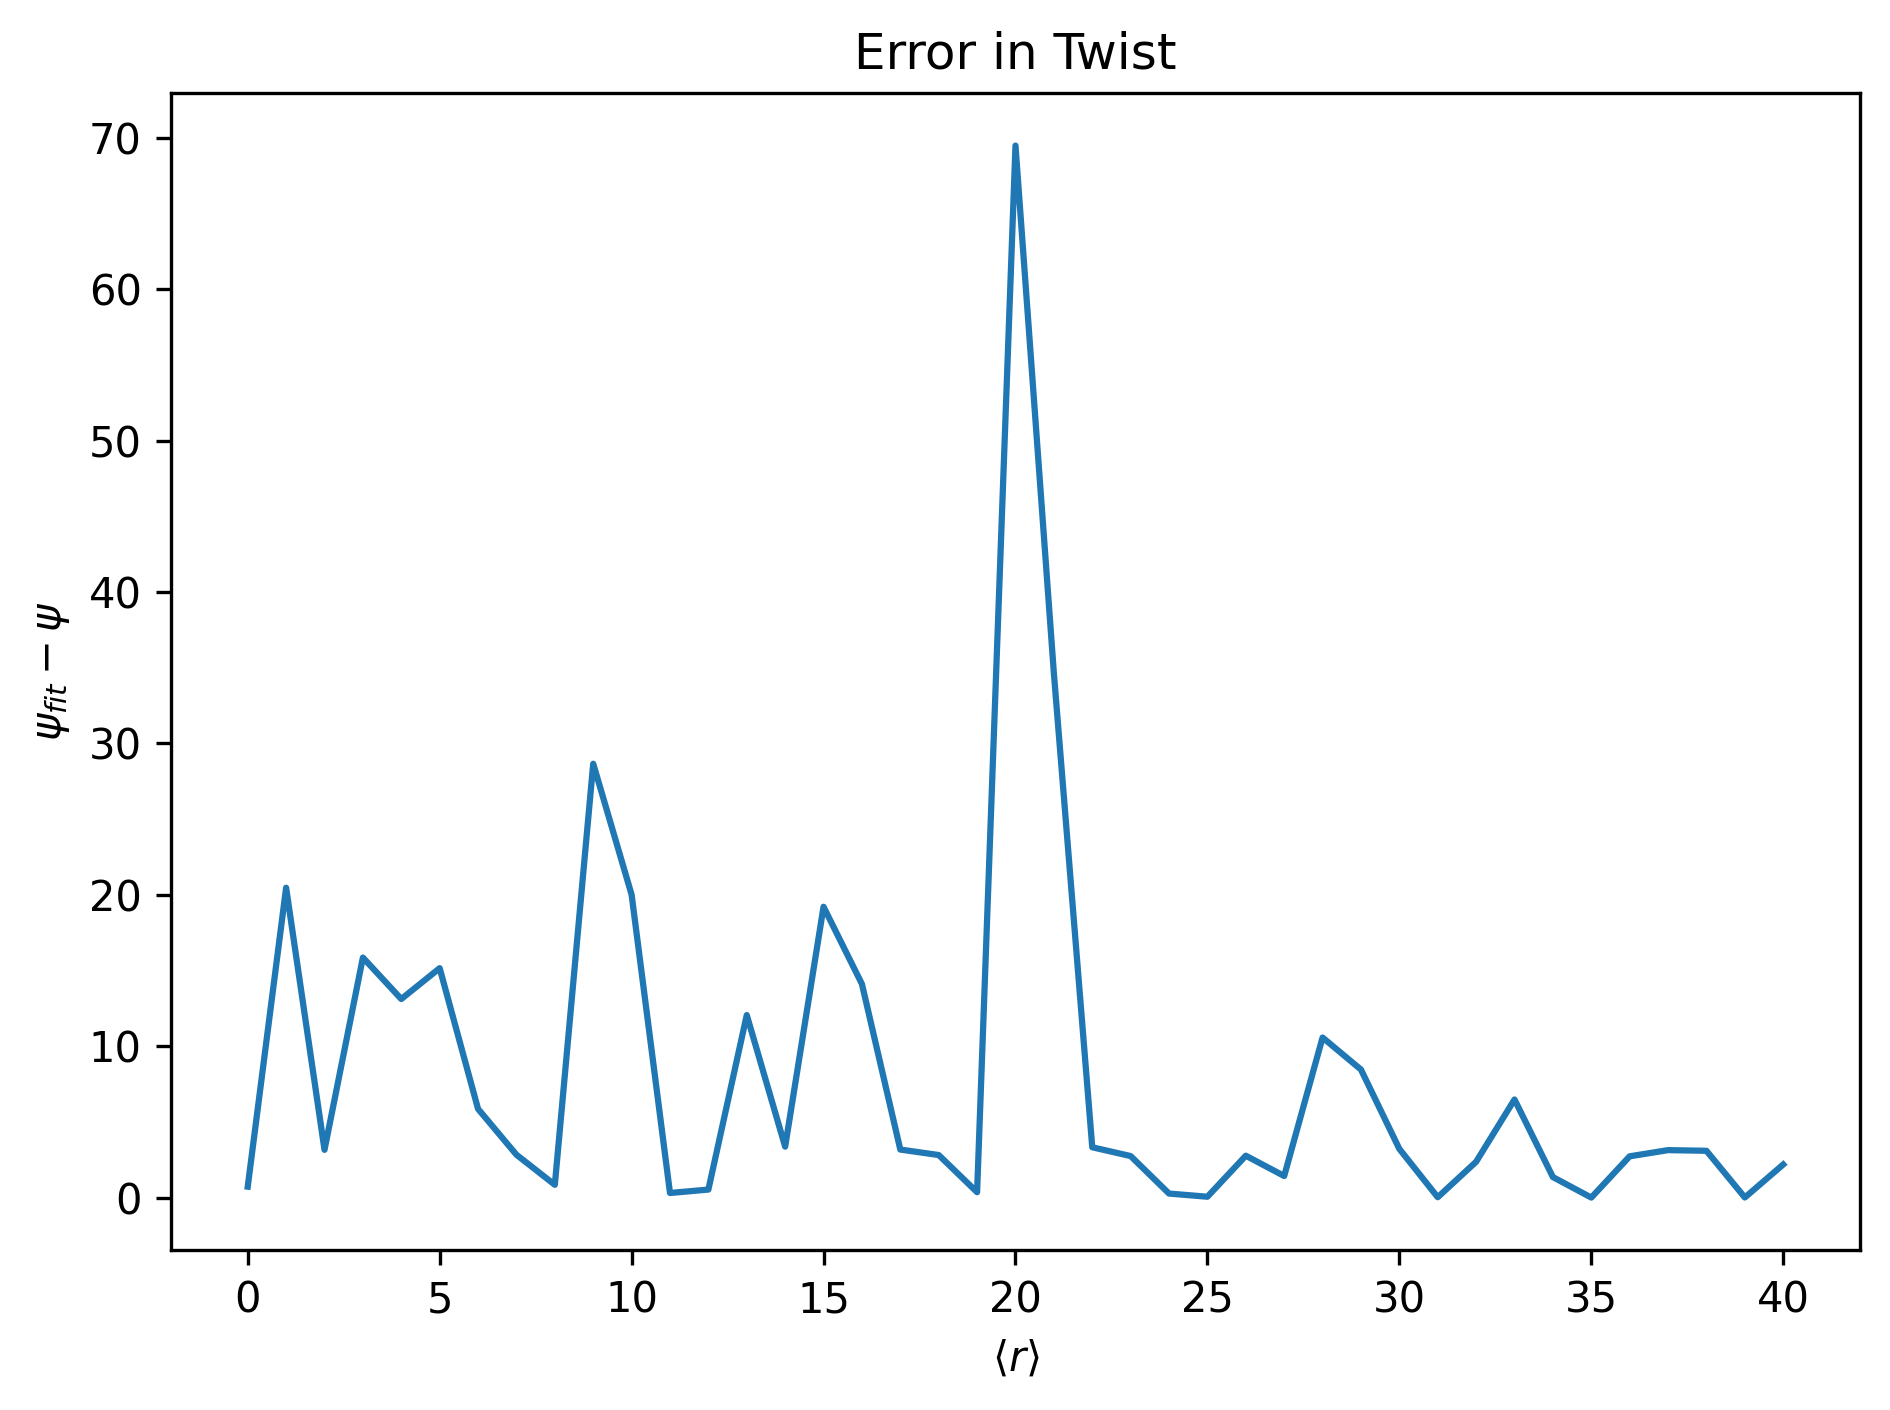

In [34]:
# Error in Psi Analysis
psi_fit = np.rad2deg(np.tan(m_rad*twist))
error = (psi_fit - psi_pre)**2

plt.figure(dpi=300)

plt.plot(range(num_mols), error)

plt.xlabel(r"$\langle r \rangle$")
plt.ylabel(r"$\psi_{fit} - \psi$")
plt.title("Error in Twist")

plt.tight_layout()
plt.show()

In [35]:
# Compare errors on the different twists
errortw0 = error
vartw0 = var_l

files_dir = "H:/colproj-data/struct-aly/files-tw0.04"

# We are just analyzing the initial condition
u_pre = md.Universe(files_dir + "/em.tpr", files_dir + "/colfib-solvion.gro")
chains_pre = u_pre.select_atoms("protein").fragments
com_pre = u_pre.select_atoms("protein").center_of_mass() /10

num_mols = int(len(chains_pre)/3)
group = "name CA"
m_pre = np.zeros(num_mols)
m_rad = np.zeros(num_mols)
vartw0_04 = np.zeros(num_mols)

for mol in range(num_mols):
    # --- Pre ---
    molecule = chains_pre[3*mol:3*mol + 3]
    molecule_coords = (molecule[0].select_atoms(group) + molecule[1].select_atoms(group)+ molecule[2].select_atoms(group)).positions /10
    rad_pre, phi_pre, z_pre = tw.cyl_proj(molecule_coords, com_pre[1], com_pre[0])
    arc_pre = rad_pre*phi_pre
    m_pre[mol], b, vartw0_04[mol] = tw.ortreglinfit(z_pre, arc_pre)
    m_rad[mol] = np.mean(rad_pre)

errortw0_04 = (np.rad2deg(np.tan(m_rad*0.04)) - np.rad2deg(np.atan(m_pre)))**2

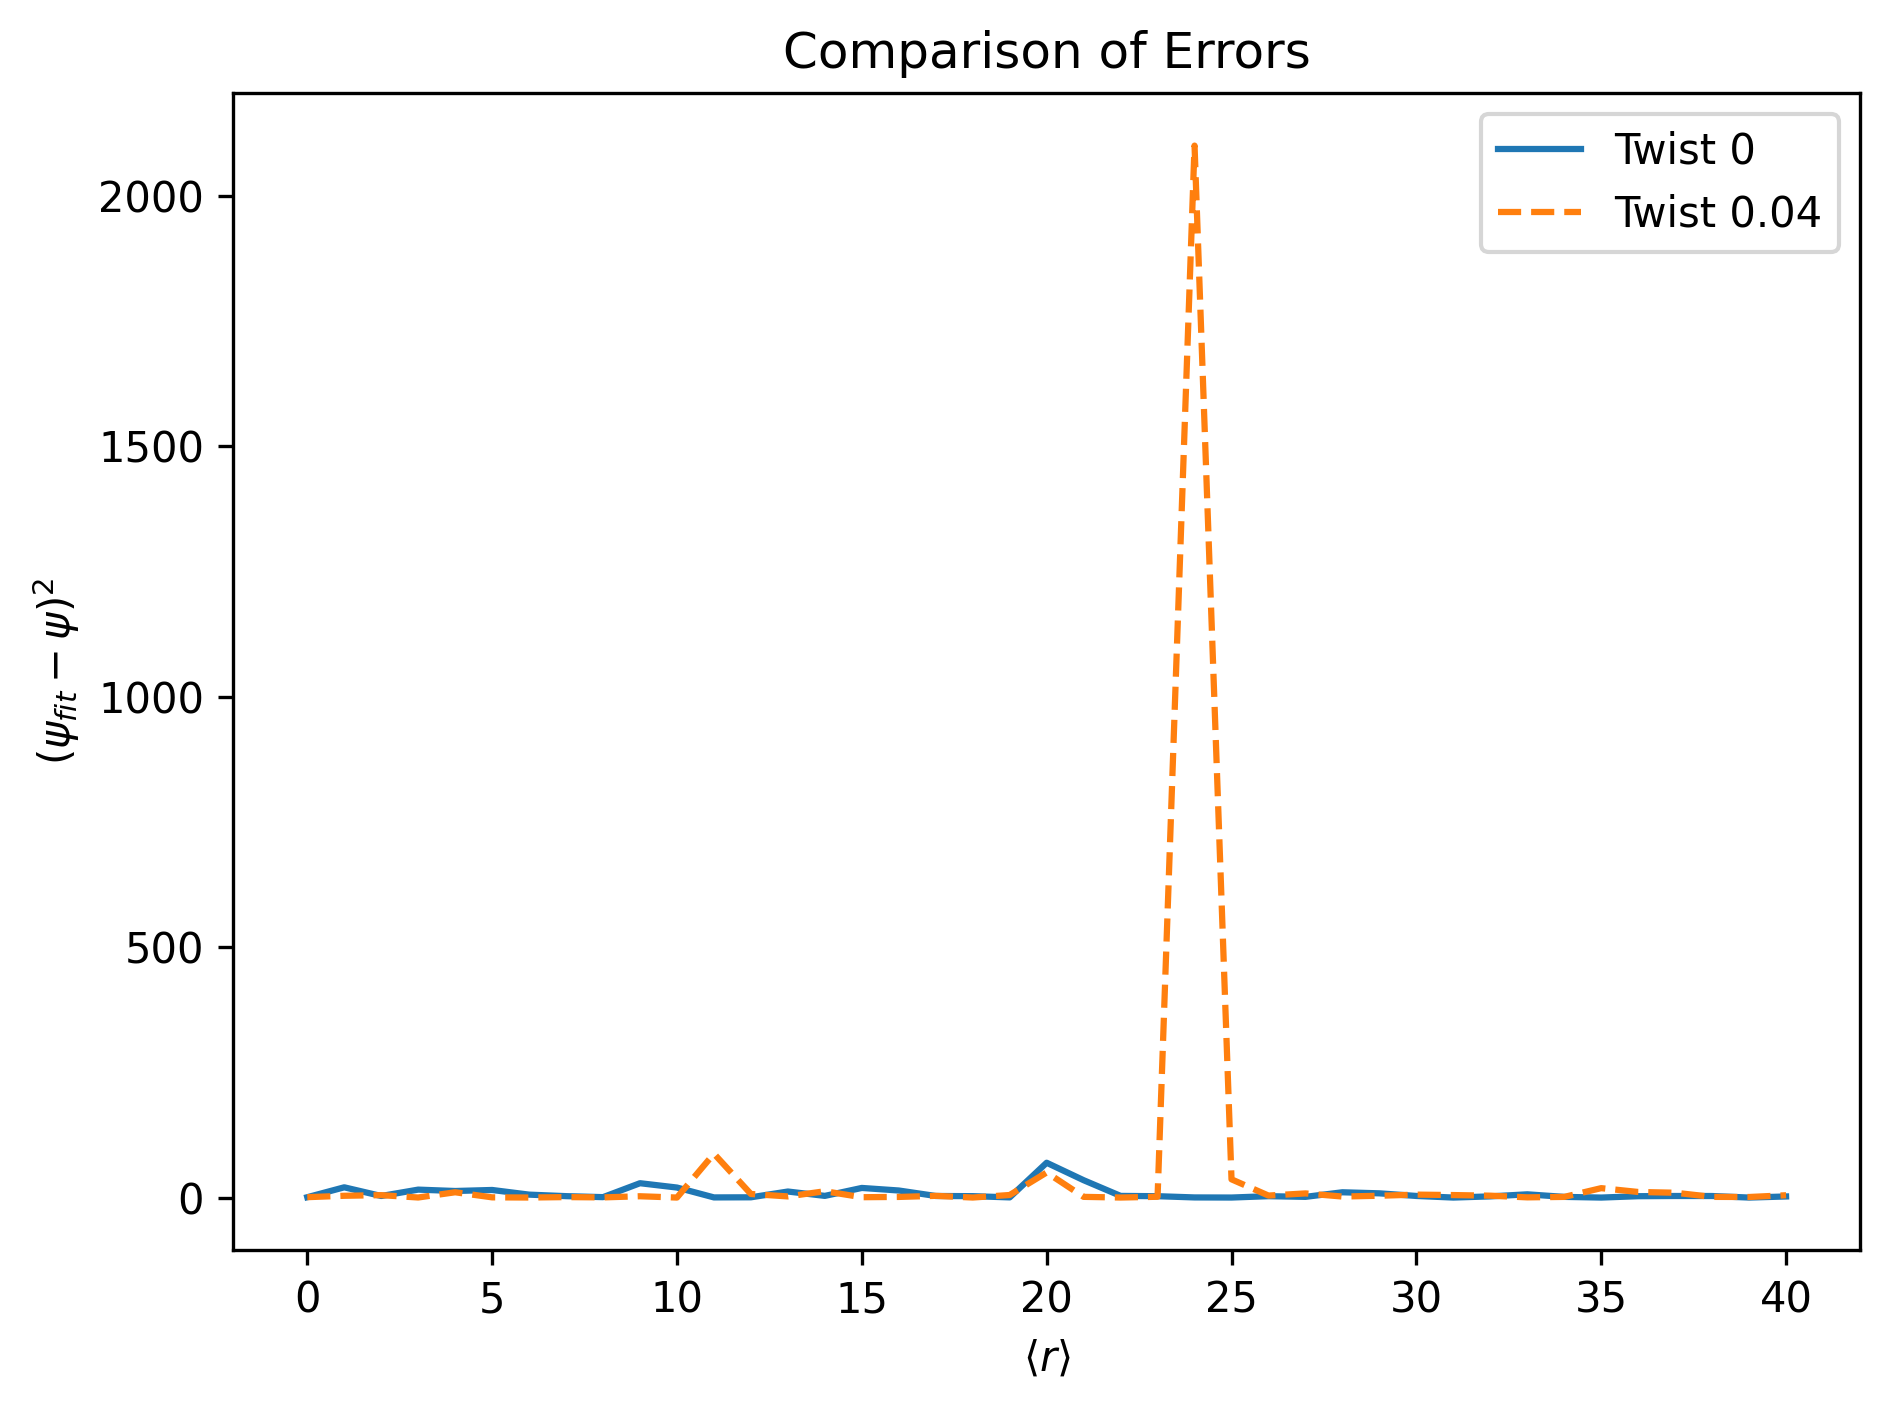

In [36]:
# Comparison of Errors
plt.figure(dpi=300)

plt.plot(range(num_mols), errortw0, label = "Twist 0")
plt.plot(range(num_mols), errortw0_04, label = "Twist 0.04", linestyle="dashed")

plt.xlabel(r"$\langle r \rangle$")
plt.ylabel(r"$(\psi_{fit} - \psi)^2$")
plt.title("Comparison of Errors")

plt.tight_layout()
plt.legend()
plt.show()

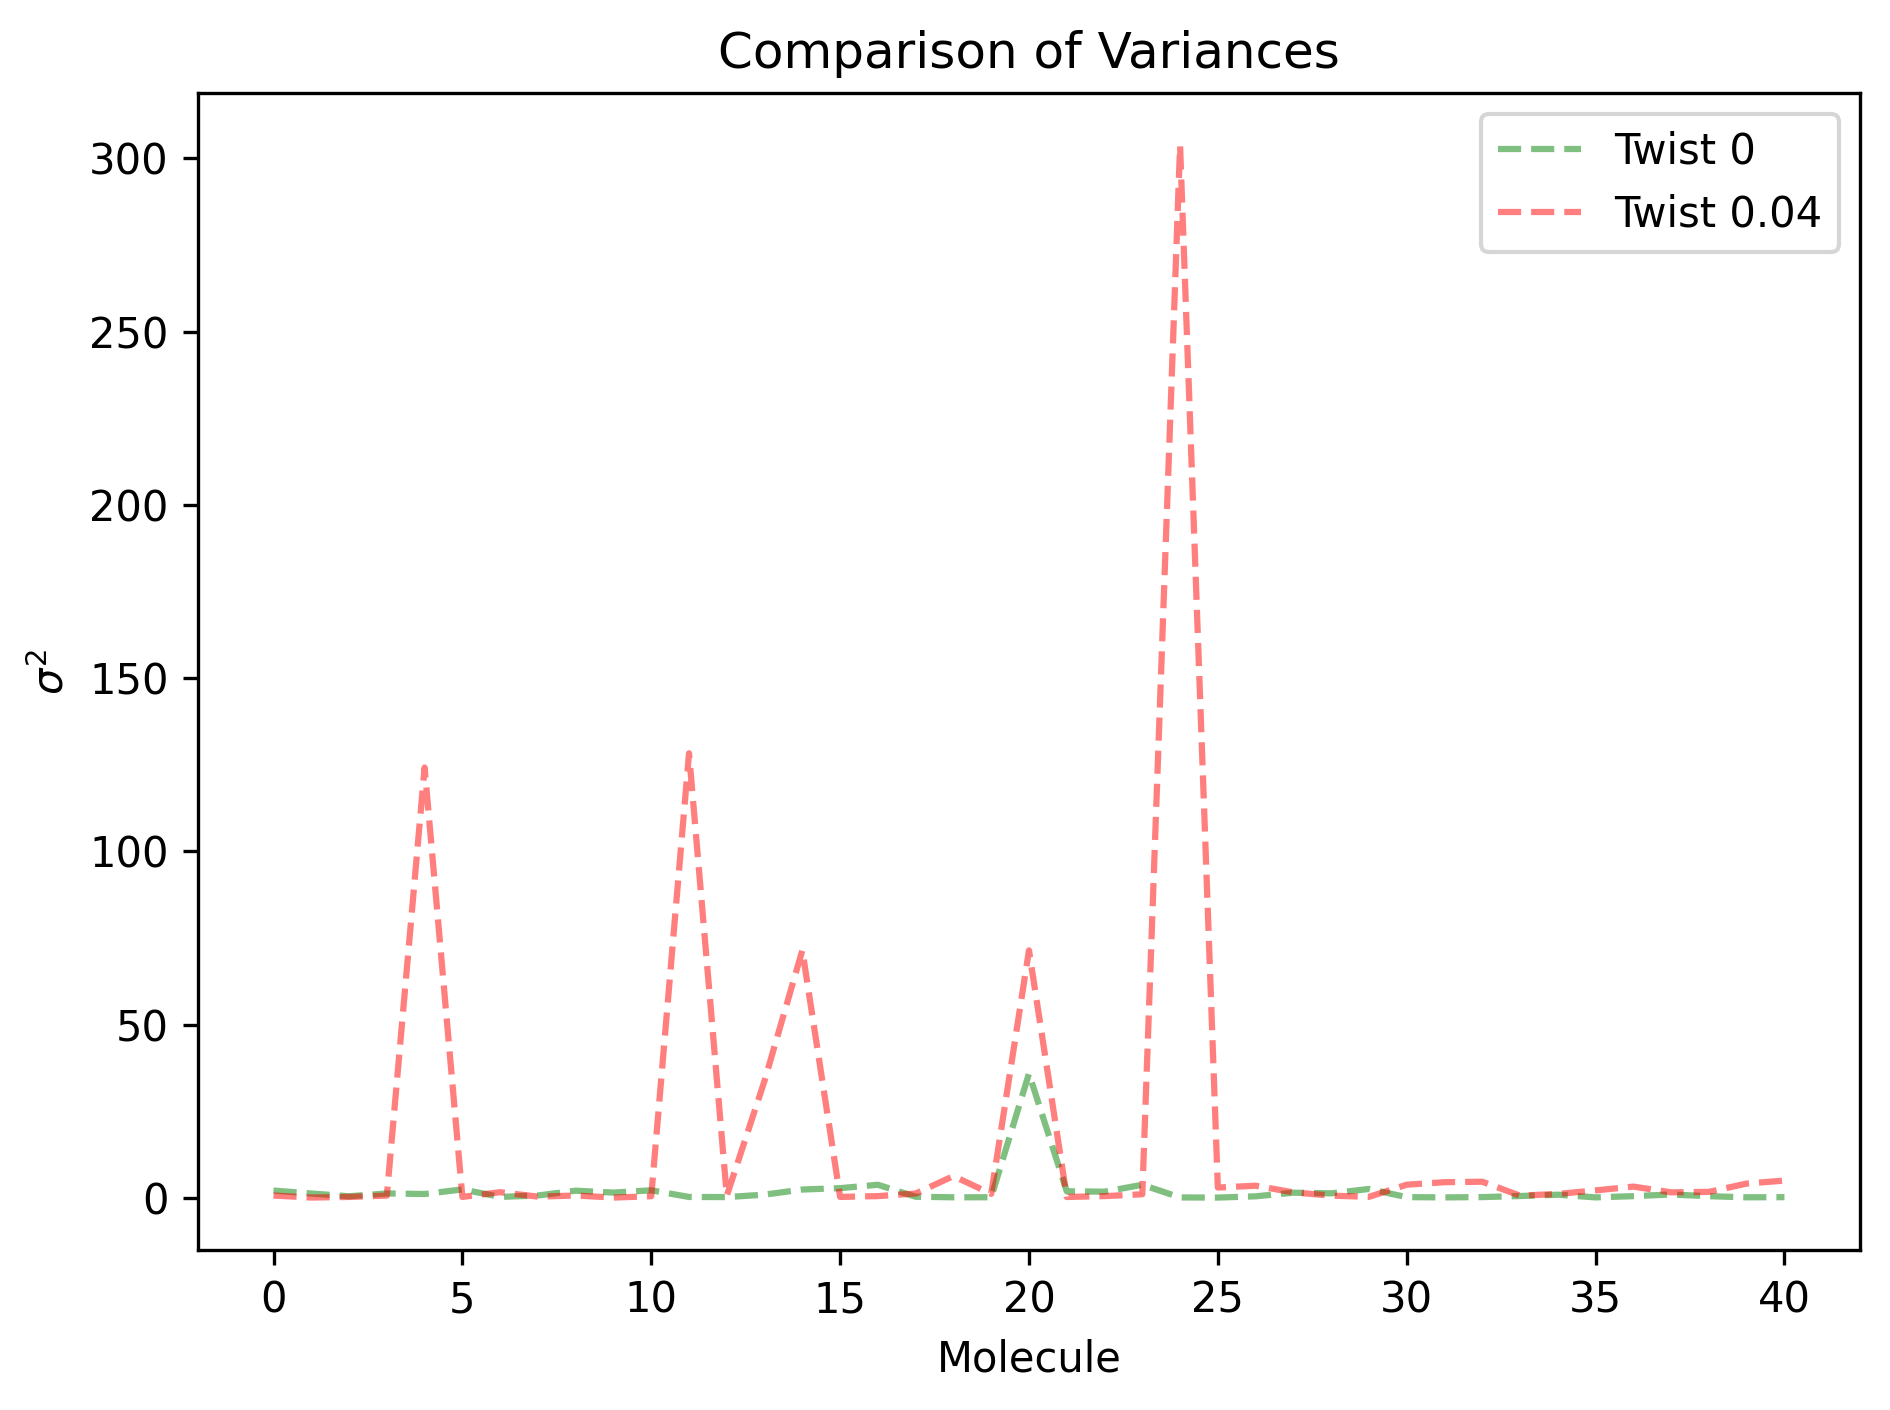

In [42]:
# --- Check Variance ---
plt.figure(dpi=300)
colors = ["g", "r"]

plt.plot(range(num_mols), vartw0, label = "Twist 0", linestyle="dashed", color=colors[0], alpha=0.5)
#plt.scatter(range(num_mols), vartw0, color=colors[0])

plt.plot(range(num_mols), vartw0_04, label = "Twist 0.04", linestyle="dashed", color=colors[1], alpha=0.5)
#plt.scatter(range(num_mols), vartw0_04, color=colors[1])

plt.xlabel(r"Molecule")
plt.ylabel(r"$\sigma^2$")
plt.title("Comparison of Variances")

plt.tight_layout()
plt.legend()
plt.show()

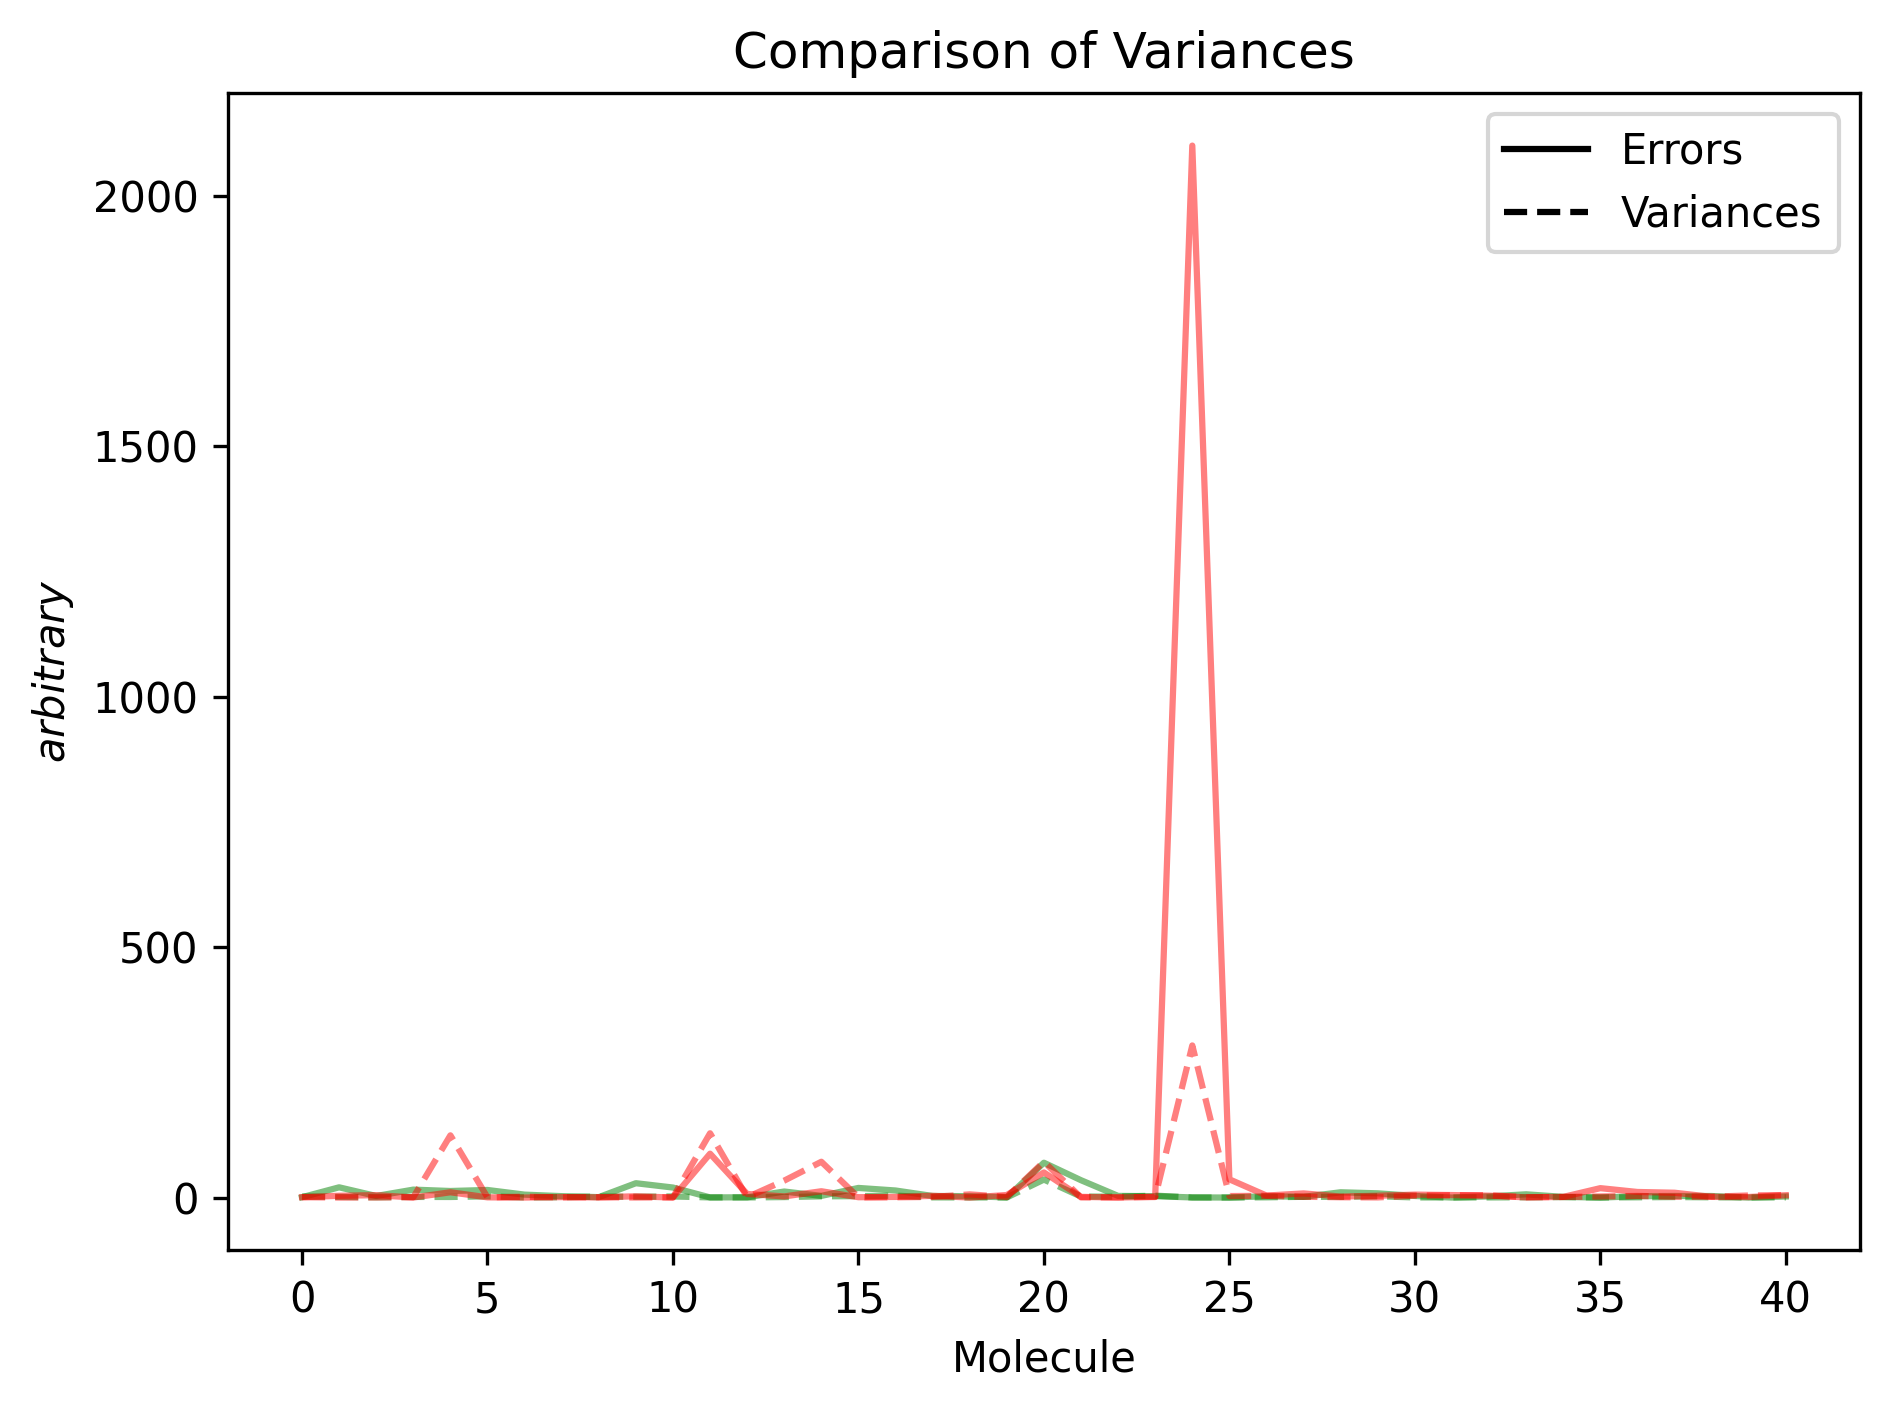

In [47]:
# --- Variance and Error Relation ---
# Error with respect to the fit line: points of tilt vs tilt expected
# Variance of the fit line
import matplotlib.lines as mlines

plt.figure(dpi=300)
colors = ["g", "r"]

plt.plot(range(num_mols), errortw0, color=colors[0], alpha=0.5)
plt.plot(range(num_mols), vartw0, label = "Twist 0", linestyle="dashed", color=colors[0], alpha=0.5)
#plt.scatter(range(num_mols), vartw0, color=colors[0])

plt.plot(range(num_mols), errortw0_04, color=colors[1], alpha=0.5)
plt.plot(range(num_mols), vartw0_04, label = "Twist 0.04", linestyle="dashed", color=colors[1], alpha=0.5)
#plt.scatter(range(num_mols), vartw0_04, color=colors[1])

plt.xlabel(r"Molecule")
plt.ylabel(r"$arbitrary$")
plt.title("Comparison of Variances")

solid = mlines.Line2D([], [], color="k", linestyle="-", label="Errors")
dashed = mlines.Line2D([], [], color="k", linestyle="--", label="Variances")

plt.legend(handles=[solid, dashed])
plt.tight_layout()
#plt.legend()
plt.show()

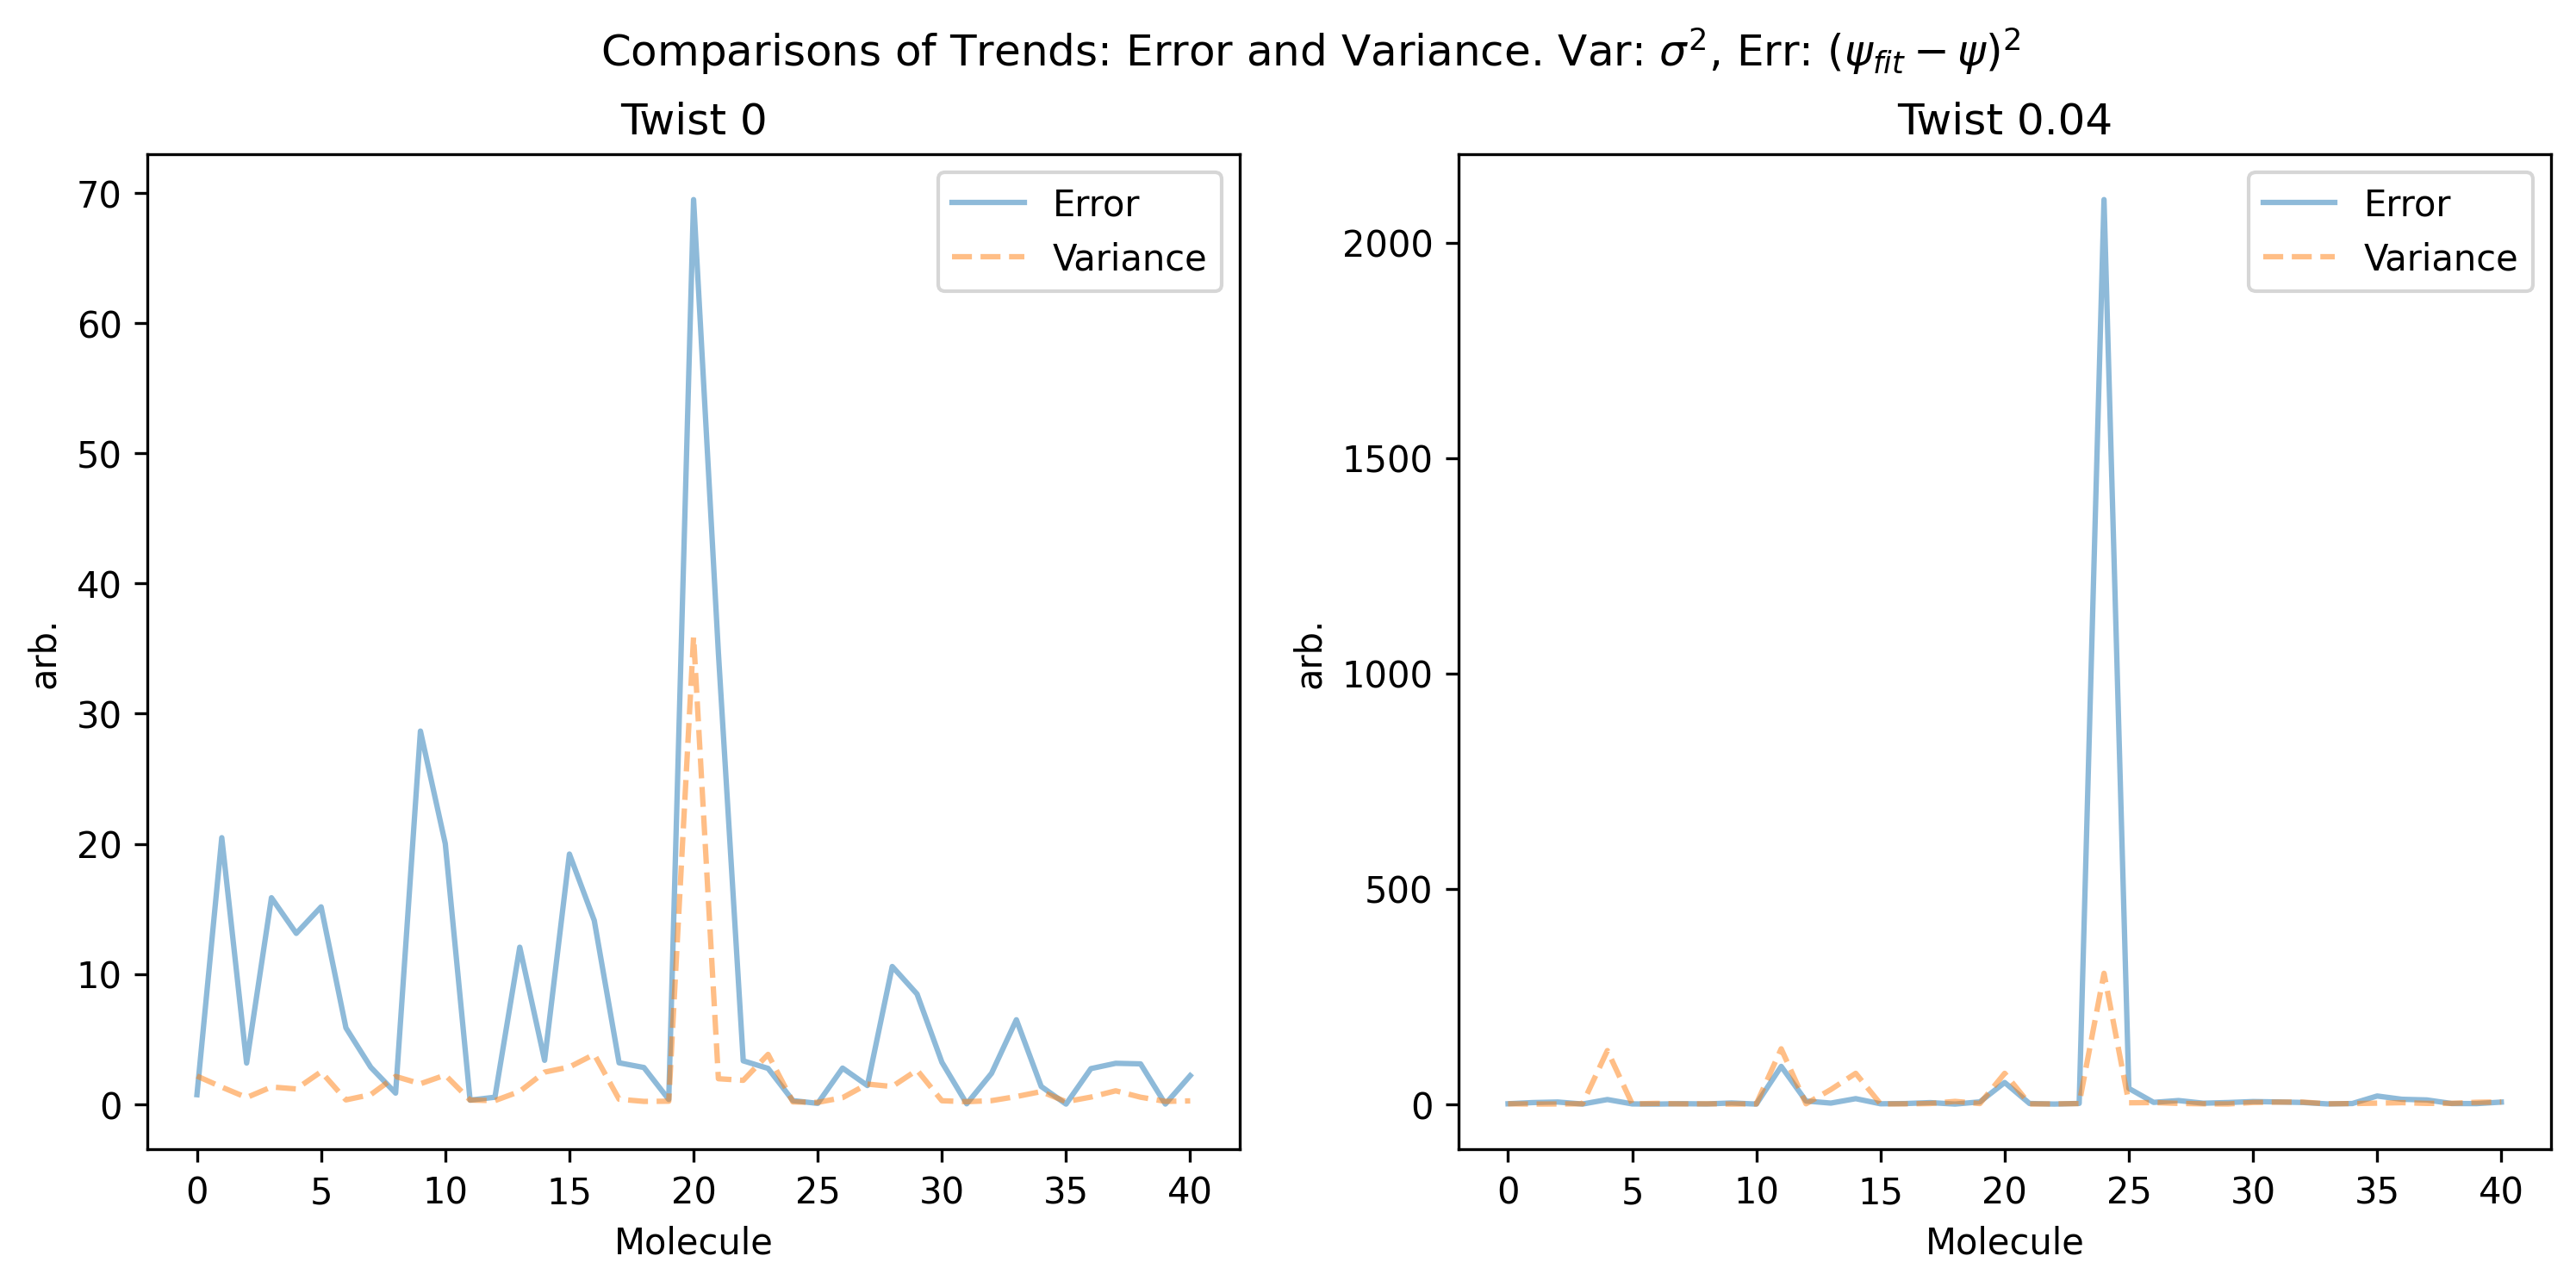

In [ ]:
# --- Side by Side ---
fig, ax = plt.subplots(1, 2, figsize=(12,5), dpi=300)

# --- Twist 0 ---
ax[0].plot(range(num_mols), errortw0, label = "Error", alpha=0.5)
ax[0].plot(range(num_mols), vartw0, label = "Variance", linestyle="dashed", alpha=0.5)
ax[0].set_xlabel(r'Molecule')
ax[0].set_ylabel(r'arb.')
ax[0].set_title(r'Twist 0')
ax[0].legend()

# --- Twist 0 ---
ax[1].plot(range(num_mols), errortw0_04, label = "Error", alpha=0.5)
ax[1].plot(range(num_mols), vartw0_04, label = "Variance", linestyle="dashed", alpha=0.5)
ax[1].set_xlabel(r'Molecule')
ax[1].set_ylabel(r'arb.')
ax[1].set_title(r'Twist 0.04')
ax[1].legend()

plt.suptitle(r"Comparisons of Trends: Error and Variance. Var: $\sigma^2$, Err: $(\psi_{fit} - \psi)^2$")
plt.show()